# Week 4 — Data Wrangling & Exploratory Data Analysis
## Speech Emotion Recognition — RAVDESS Dataset

**Goals:** Parse RAVDESS filenames into a metadata table, explore class distributions and audio properties

**Deliverable:** Data loading pipeline + EDA notebook

## 1. Setup

In [24]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

DATA_DIR    = pathlib.Path('../../data')
FIGURES_DIR = pathlib.Path('../figures')
FIGURES_DIR.mkdir(exist_ok=True)

assert DATA_DIR.exists(), f'Data directory not found: {DATA_DIR.resolve()}'
print(f'Data: {DATA_DIR.resolve()}')

Data: C:\Users\zacha\OneDrive\Documents\miami\cse432\Project_CSE432-532\data


## 2. Filename Parsing & Metadata Table

Each RAVDESS filename encodes 7 fields separated by hyphens:

| Position | Field | Values |
|---|---|---|
| 1 | modality | 03 = audio-only |
| 2 | vocal_channel | 01 = speech, 02 = song |
| **3** | **emotion** | **01 = neutral … 08 = surprised** |
| 4 | intensity | 01 = normal, 02 = strong |
| 5 | statement | 01 or 02 |
| 6 | repetition | 01 or 02 |
| 7 | actor | 01–24 (odd = male, even = female) |

In [25]:
EMOTION_MAP = {
    '01': 'neutral', '02': 'calm',    '03': 'happy', '04': 'sad',
    '05': 'angry',   '06': 'fearful', '07': 'disgust','08': 'surprised',
}
EMOTION_ORDER = list(EMOTION_MAP.values())


def parse_filename(filepath: pathlib.Path) -> dict | None:
    """Return a metadata dict for one RAVDESS .wav file, or None if malformed."""
    parts = filepath.stem.split('-')
    if len(parts) != 7:
        return None
    actor_id = int(parts[6])
    return {
        'filepath':      str(filepath),
        'vocal_channel': 'speech' if parts[1] == '01' else 'song',
        'emotion_id':    int(parts[2]),
        'emotion':       EMOTION_MAP.get(parts[2], parts[2]),
        'intensity':     'normal' if parts[3] == '01' else 'strong',
        'actor_id':      actor_id,
        'gender':        'male' if actor_id % 2 == 1 else 'female',
    }


def build_metadata(data_dir: pathlib.Path) -> pd.DataFrame:
    """Scan Actor_XX directories and return one-row-per-file metadata DataFrame."""
    records = []
    for actor_dir in sorted(data_dir.iterdir()):
        if not (actor_dir.is_dir() and actor_dir.name.startswith('Actor_')):
            continue
        for wav in sorted(actor_dir.glob('*.wav')):
            record = parse_filename(wav)
            if record:
                records.append(record)

    df = pd.DataFrame(records)
    df['emotion'] = pd.Categorical(df['emotion'], categories=EMOTION_ORDER)
    return df


df = build_metadata(DATA_DIR)
print(f'Loaded {len(df):,} files')
df.head(3)

Loaded 2,452 files


,filepath,vocal_channel,emotion_id,emotion,intensity,actor_id,gender
0,..\..\data\Actor_01\03-01-01-01-01-01-01.wav,speech,1,neutral,normal,1,male
1,..\..\data\Actor_01\03-01-01-01-01-02-01.wav,speech,1,neutral,normal,1,male
2,..\..\data\Actor_01\03-01-01-01-02-01-01.wav,speech,1,neutral,normal,1,male


## 3. Dataset Overview

In [26]:
print(f'Total:    {len(df):,}')
print(f'Speech:   {(df.vocal_channel == "speech").sum():,}')
print(f'Song:     {(df.vocal_channel == "song").sum():,}')
print(f'Actors:   {df.actor_id.nunique()}')
print(f'Classes:  {df.emotion.nunique()}')
print()
print(df.groupby('emotion', observed=True).size().rename('count').to_string())

Total:    2,452
Speech:   1,440
Song:     1,012
Actors:   24
Classes:  8

emotion
neutral      188
calm         376
happy        376
sad          376
angry        376
fearful      376
disgust      192
surprised    192


## 4. Class Distribution

C:\Users\zacha\AppData\Local\Temp\ipykernel_30600\784948660.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='muted', ax=axes[0])


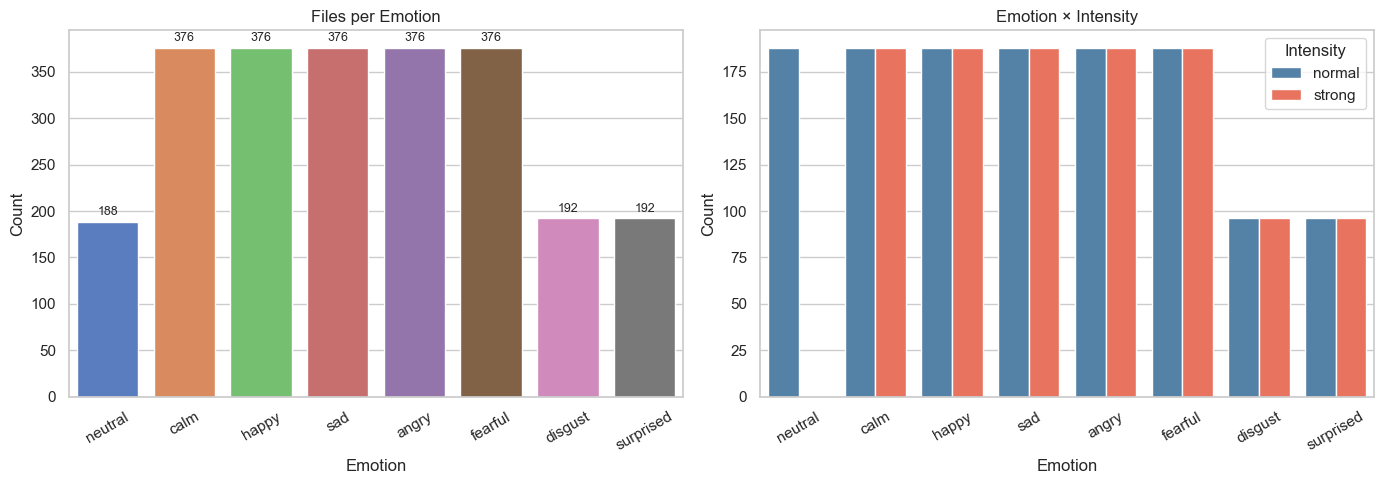

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total files per emotion
counts = df.groupby('emotion', observed=True).size()
sns.barplot(x=counts.index, y=counts.values, palette='muted', ax=axes[0])
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 4,
                 int(bar.get_height()), ha='center', va='bottom', fontsize=9)
axes[0].set(title='Files per Emotion', xlabel='Emotion', ylabel='Count')
axes[0].tick_params(axis='x', rotation=30)

# Emotion × intensity
ei = df.groupby(['emotion', 'intensity'], observed=True).size().rename('count').reset_index()
sns.barplot(data=ei, x='emotion', y='count', hue='intensity',
            palette={'normal': 'steelblue', 'strong': 'tomato'}, ax=axes[1])
axes[1].set(title='Emotion × Intensity', xlabel='Emotion', ylabel='Count')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Intensity')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_distribution.png', bbox_inches='tight')
plt.show()

**Discussion:** The dataset is broadly balanced. Neutral has roughly half as many samples as other emotions because it was only recorded at normal intensity: all other emotions have both normal and strong variants. This imbalance should be handled

## 5. Audio Duration Analysis

In [28]:
# Read audio properties from file headers (no decoding needed)
audio_props = []
for filepath in df['filepath']:
    info = sf.info(filepath)
    audio_props.append({'duration_s': info.duration, 'sample_rate': info.samplerate, 'channels': info.channels})

df = pd.concat([df, pd.DataFrame(audio_props, index=df.index)], axis=1)
print(df[['duration_s', 'sample_rate', 'channels']].describe().round(3))

       duration_s  sample_rate  channels
count    2452.000       2452.0  2452.000
mean        4.092      48000.0     1.002
std         0.598          0.0     0.049
min         2.936      48000.0     1.000
25%         3.604      48000.0     1.000
50%         4.004      48000.0     1.000
75%         4.538      48000.0     1.000
max         6.373      48000.0     2.000


C:\Users\zacha\AppData\Local\Temp\ipykernel_30600\3852483784.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(dur_by_emo, labels=EMOTION_ORDER, patch_artist=True)


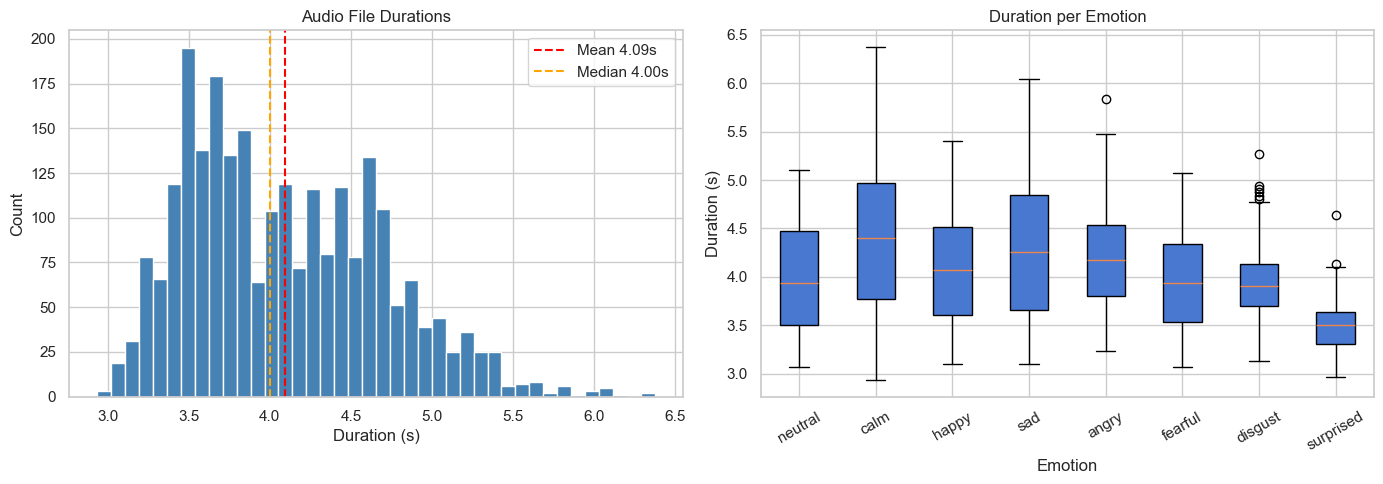

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Duration histogram
axes[0].hist(df['duration_s'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(df['duration_s'].mean(),   color='red',    linestyle='--',
                label=f'Mean {df["duration_s"].mean():.2f}s')
axes[0].axvline(df['duration_s'].median(), color='orange', linestyle='--',
                label=f'Median {df["duration_s"].median():.2f}s')
axes[0].set(title='Audio File Durations', xlabel='Duration (s)', ylabel='Count')
axes[0].legend()

# Duration per emotion
dur_by_emo = [df.loc[df['emotion'] == e, 'duration_s'].values for e in EMOTION_ORDER]
axes[1].boxplot(dur_by_emo, labels=EMOTION_ORDER, patch_artist=True)
axes[1].set(title='Duration per Emotion', xlabel='Emotion', ylabel='Duration (s)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'duration_distribution.png', bbox_inches='tight')
plt.show()

**Discussion:** Durations range from ~3 to ~6 seconds with a mean near 4 seconds. Since files have different lengths, we cannot feed raw audio directly into classical ML models. The frame-level summary-statistics approach in Week 5 solves this by producing a fixed-length vector per file.

## 7. Data Audit

In [31]:
missing_actors = set(range(1, 25)) - set(df['actor_id'].unique())

checks = [
    ('Speech files',           (df.vocal_channel == 'speech').sum(),                    1440),
    ('Song files',             (df.vocal_channel == 'song').sum(),                      1012),
    ('Non-48kHz files',        (df.sample_rate != 48000).sum(),                            0),
    ('Non-mono files',         (df.channels != 1).sum(),                                   0),
    ('Actor 18 song files',    ((df.actor_id == 18) & (df.vocal_channel == 'song')).sum(), 0),
    ('Missing actors',         len(missing_actors),                                        0),
]

for label, actual, expected in checks:
    status = 'OK' if actual == expected else 'MISMATCH'
    print(f'  {label:<25} expected={expected}  actual={actual}  [{status}]')

  Speech files              expected=1440  actual=1440  [OK]
  Song files                expected=1012  actual=1012  [OK]
  Non-48kHz files           expected=0  actual=0  [OK]
  Non-mono files            expected=0  actual=6  [MISMATCH]
  Actor 18 song files       expected=0  actual=0  [OK]
  Missing actors            expected=0  actual=0  [OK]


## 8. Save Metadata

In [32]:
out = pathlib.Path('../data/metadata.csv')
out.parent.mkdir(exist_ok=True)
df.to_csv(out, index=False)
print(f'Saved {df.shape} → {out.resolve()}')

Saved (2452, 10) → C:\Users\zacha\OneDrive\Documents\miami\cse432\Project_CSE432-532\SER_Project\data\metadata.csv
